# Capstone 24.1 — Notebook 3: Modeling (Resolution-Time Regression)

**Author:** Sravanthi Gandu

**Modeling task.** A **supervised regression** problem: predict a ticket's
`resolution_days` from features known **at intake**. We compare several model families with
**5-fold cross-validation**, tune the strongest ones with **`GridSearchCV`**, and report
final performance on a held-out test set.

We model on the **log scale** (`log1p(resolution_days)`) because resolution time is strongly
right-skewed, and we back-transform predictions with `expm1` so every error is reported in
**real days**. A naive mean predictor anchors the comparison so we can see how much signal
the intake features actually add.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate, KFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import RidgeCV, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             make_scorer)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
CV = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

## 1. Build the modeling frame (resolved tickets with a valid duration)

In [2]:
df = pd.read_csv("../data/cpt_clean.csv")

# Only rows with a genuine, positive resolution duration can train the regressor
model_df = df[df["resolution_days"].notna() & (df["resolution_days"] > 0)].copy()

# Log target tames the skew; we invert with expm1 to report errors in real days
model_df["y_log"] = np.log1p(model_df["resolution_days"])

print(f"Modeling rows: {len(model_df):,}")
print(f"Median resolution: {model_df['resolution_days'].median():.1f} days | "
      f"mean: {model_df['resolution_days'].mean():.1f} days")

Modeling rows: 6,615
Median resolution: 15.2 days | mean: 125.7 days


## 2. Feature set — intake-time only (no leakage)

Every feature below is known the moment the ticket is created. Post-hoc fields such as
`status`, `status_reason`, and any `*_date` after creation are deliberately excluded so the
model reflects what is actually knowable at intake.

In [3]:
CATEGORICAL = ["order_type", "geo", "market_segment", "offer_family",
               "cloud", "type", "requestor_system"]
NUMERIC = ["offer_quantity", "line_items_per_ticket",
           "create_month", "create_week", "create_dow", "create_hour"]

X = model_df[CATEGORICAL + NUMERIC]
y = model_df["y_log"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")

Train: 5,292 rows | Test: 1,323 rows


## 3. Preprocessing pipeline

Categoricals are one-hot encoded (`min_frequency` collapses rare levels to keep the matrix
compact); numerics are median-imputed and standardized. Wrapping this in a
`ColumnTransformer` means every model below is trained and cross-validated on **identical,
leak-free** preprocessing — the transforms are fit inside each CV fold, never on the test
data.

In [4]:
categorical_tf = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="UNKNOWN")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=50)),
])
numeric_tf = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])
preprocess = ColumnTransformer([
    ("cat", categorical_tf, CATEGORICAL),
    ("num", numeric_tf, NUMERIC),
])

def make_pipe(model):
    """Attach any estimator to the shared preprocessing block."""
    return Pipeline([("prep", preprocess), ("model", model)])

## 4. Model comparison with 5-fold cross-validation

We benchmark five model families against the naive baseline. Because the target is fit on
the log scale but the business cares about **days**, we score with a custom **MAE-in-days**
scorer (back-transforming each fold's predictions with `expm1`) alongside the log-scale R².
Cross-validation gives a mean ± standard-deviation estimate, so we judge models on stable
performance rather than one lucky split.

In [5]:
# Custom scorer: mean absolute error expressed in real days (lower is better)
def _mae_days(y_true_log, y_pred_log):
    return mean_absolute_error(np.expm1(y_true_log), np.expm1(y_pred_log))

mae_days = make_scorer(_mae_days, greater_is_better=False)
scoring = {"MAE_days": mae_days, "R2_log": "r2"}

candidates = {
    "Baseline (mean)":   DummyRegressor(strategy="mean"),
    "Ridge":             RidgeCV(alphas=np.logspace(-2, 3, 20)),
    "Lasso":             Lasso(alpha=0.01, max_iter=10000, random_state=RANDOM_STATE),
    "ElasticNet":        ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000,
                                    random_state=RANDOM_STATE),
    "Random Forest":     RandomForestRegressor(n_estimators=300, n_jobs=-1,
                                               random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

rows = []
for name, est in candidates.items():
    cvres = cross_validate(make_pipe(est), X_train, y_train, cv=CV,
                           scoring=scoring, n_jobs=-1)
    rows.append({
        "Model": name,
        "CV MAE (days)": -cvres["test_MAE_days"].mean(),
        "MAE std": cvres["test_MAE_days"].std(),  # spread across folds (days)
        "CV R2 (log)": cvres["test_R2_log"].mean(),
        "R2 std": cvres["test_R2_log"].std(),
    })

cv_results = pd.DataFrame(rows).sort_values("CV MAE (days)").reset_index(drop=True)
cv_results.round(3)

,Model,CV MAE (days),MAE std,CV R2 (log),R2 std
0,Random Forest,100.923,2.781,0.411,0.017
1,Gradient Boosting,101.067,3.714,0.464,0.022
2,Ridge,112.997,3.777,0.290,0.015
3,ElasticNet,113.813,3.912,0.279,0.013
4,Lasso,114.185,3.935,0.271,0.014
5,Baseline (mean),122.710,5.227,-0.001,0.002


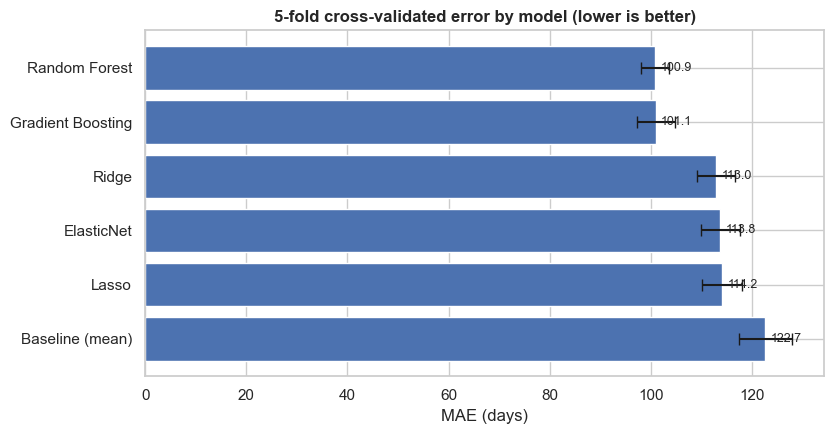

In [6]:
# Visual comparison of cross-validated error (mean +/- std, in days)
fig, ax = plt.subplots(figsize=(8.5, 4.5))
order = cv_results.sort_values("CV MAE (days)")
ax.barh(order["Model"], order["CV MAE (days)"],
        xerr=order["MAE std"], color="#4C72B0", capsize=4)
ax.invert_yaxis()
ax.set_title("5-fold cross-validated error by model (lower is better)",
             fontsize=12, weight="bold")
ax.set_xlabel("MAE (days)")
ax.set_ylabel("")
for i, v in enumerate(order["CV MAE (days)"]):
    ax.text(v + 1, i, f"{v:.1f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 5. Hyperparameter tuning with `GridSearchCV`

The two strongest families from the cross-validation above are tuned with an exhaustive
grid search (same 5-fold split, scored on MAE-in-days). Grid search refits on the best
parameter combination automatically, so `best_estimator_` is ready for final evaluation.

In [7]:
# --- Tune Gradient Boosting (captures non-linear interactions) ---
gb_pipe = make_pipe(GradientBoostingRegressor(random_state=RANDOM_STATE))
gb_grid = {
    "model__n_estimators": [200, 400],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3],
    "model__subsample": [0.8, 1.0],
}
gb_search = GridSearchCV(gb_pipe, gb_grid, scoring=mae_days, cv=CV, n_jobs=-1)
gb_search.fit(X_train, y_train)
print("Gradient Boosting")
print("  best params:", {k.replace('model__', ''): v
                          for k, v in gb_search.best_params_.items()})
print(f"  best CV MAE: {-gb_search.best_score_:.1f} days")

Gradient Boosting
  best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 400, 'subsample': 0.8}
  best CV MAE: 97.7 days


In [8]:
# --- Tune ElasticNet (regularized linear reference) ---
en_pipe = make_pipe(ElasticNet(max_iter=10000, random_state=RANDOM_STATE))
en_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1.0],
    "model__l1_ratio": [0.2, 0.5, 0.8],
}
en_search = GridSearchCV(en_pipe, en_grid, scoring=mae_days, cv=CV, n_jobs=-1)
en_search.fit(X_train, y_train)
print("ElasticNet")
print("  best params:", {k.replace('model__', ''): v
                         for k, v in en_search.best_params_.items()})
print(f"  best CV MAE: {-en_search.best_score_:.1f} days")

ElasticNet
  best params: {'alpha': 0.001, 'l1_ratio': 0.2}
  best CV MAE: 113.0 days


## 6. Final evaluation on the held-out test set

In [9]:
# Fit the reference models on the full training set for a like-for-like test comparison
dummy = make_pipe(DummyRegressor(strategy="mean")).fit(X_train, y_train)
ridge = make_pipe(RidgeCV(alphas=np.logspace(-2, 3, 20))).fit(X_train, y_train)

final_models = {
    "Baseline (mean)":        dummy,
    "Ridge":                  ridge,
    "ElasticNet (tuned)":     en_search.best_estimator_,
    "Gradient Boosting (tuned)": gb_search.best_estimator_,
}

def evaluate(model, name):
    pred_log = model.predict(X_test)
    pred_days, true_days = np.expm1(pred_log), np.expm1(y_test)
    return {
        "Model": name,
        "MAE (days)": mean_absolute_error(true_days, pred_days),
        "RMSE (days)": np.sqrt(mean_squared_error(true_days, pred_days)),
        "R2 (log scale)": r2_score(y_test, pred_log),
    }

test_results = pd.DataFrame([evaluate(m, n) for n, m in final_models.items()]).round(3)
test_results

,Model,MAE (days),RMSE (days),R2 (log scale)
0,Baseline (mean),112.752,264.146,-0.001
1,Ridge,106.590,249.140,0.281
2,ElasticNet (tuned),106.643,249.318,0.281
3,Gradient Boosting (tuned),90.646,220.847,0.476


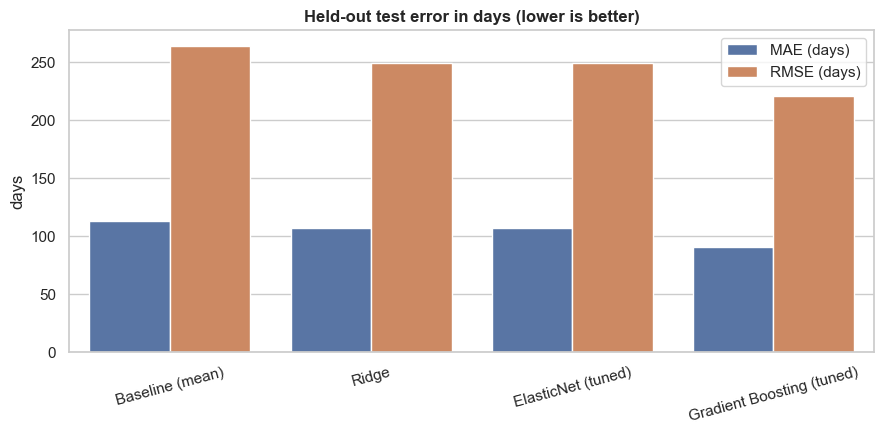

In [10]:
# Visual comparison of test-set error in days
plot_df = test_results.melt(id_vars="Model", value_vars=["MAE (days)", "RMSE (days)"],
                            var_name="metric", value_name="value")
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=plot_df, x="Model", y="value", hue="metric", ax=ax)
ax.set_title("Held-out test error in days (lower is better)",
             fontsize=12, weight="bold")
ax.set_xlabel("")
ax.set_ylabel("days")
ax.tick_params(axis="x", rotation=15)
ax.legend(title="")
plt.tight_layout()
plt.show()

## 7. Diagnostics — predicted vs. actual & residuals

Error metrics summarize; diagnostics show *where* the model works. We plot the tuned
Gradient Boosting model's predictions against the truth (on the log scale it was fit) and the
residual pattern, to confirm it is not systematically biased.

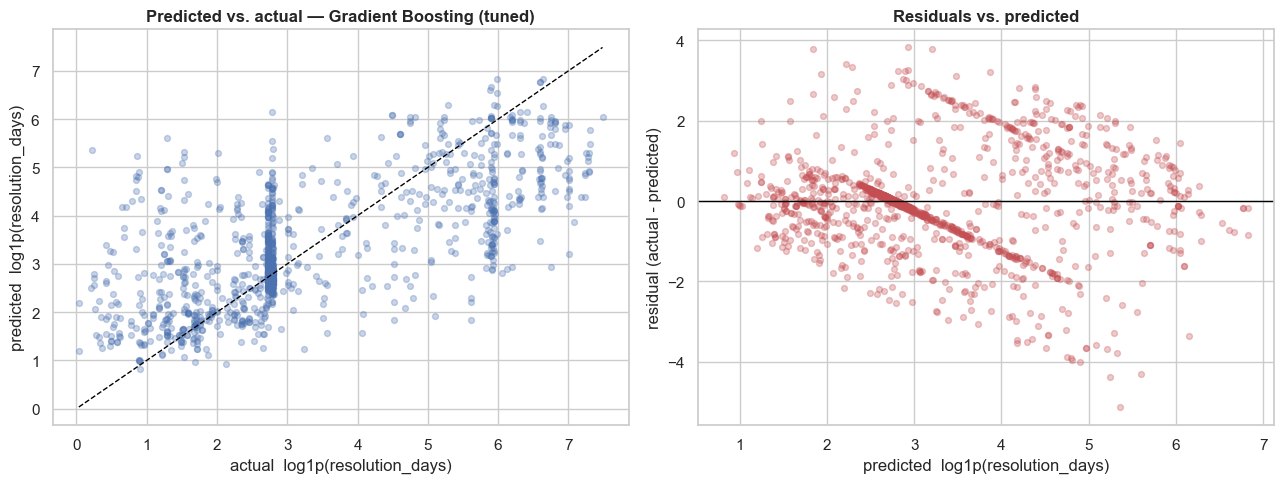

In [11]:
best_name = test_results.sort_values("MAE (days)").iloc[0]["Model"]
best_model = final_models[best_name]
pred_log = best_model.predict(X_test)
resid = y_test.values - pred_log

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Predicted vs actual (log1p days)
axes[0].scatter(y_test, pred_log, alpha=0.3, s=18, color="#4C72B0")
lims = [min(y_test.min(), pred_log.min()), max(y_test.max(), pred_log.max())]
axes[0].plot(lims, lims, "--", color="black", lw=1)
axes[0].set_title(f"Predicted vs. actual — {best_name}", fontsize=12, weight="bold")
axes[0].set_xlabel("actual  log1p(resolution_days)")
axes[0].set_ylabel("predicted  log1p(resolution_days)")

# Residuals vs predicted
axes[1].scatter(pred_log, resid, alpha=0.3, s=18, color="#C44E52")
axes[1].axhline(0, color="black", lw=1)
axes[1].set_title("Residuals vs. predicted", fontsize=12, weight="bold")
axes[1].set_xlabel("predicted  log1p(resolution_days)")
axes[1].set_ylabel("residual (actual - predicted)")

plt.tight_layout()
plt.show()

## 8. What drives resolution time?

Two complementary views: **Gradient Boosting feature importances** (which inputs the
non-linear model relies on most) and **Ridge coefficients** (the *direction* — which levels
push resolution slower vs. faster). Together they give operations a ranked, human-readable
list of the "at-risk" signals.

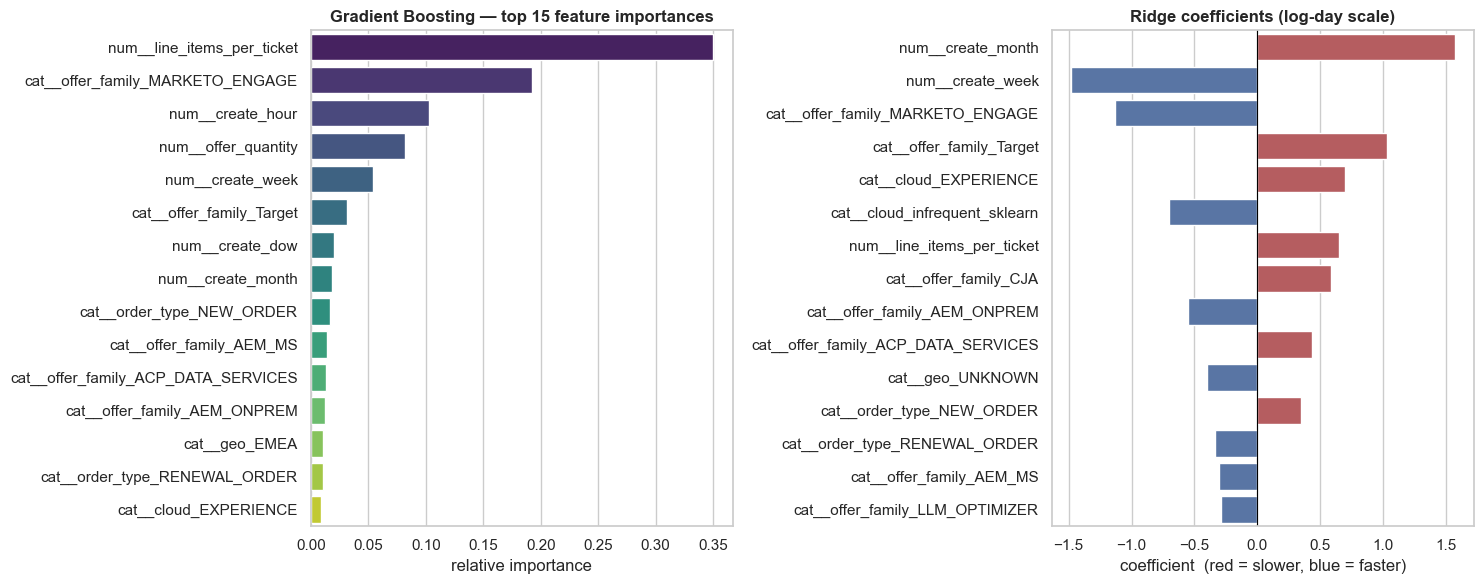

In [12]:
# --- Gradient Boosting importances ---
gb_best = gb_search.best_estimator_
feat_names = gb_best.named_steps["prep"].get_feature_names_out()
importances = pd.Series(gb_best.named_steps["model"].feature_importances_,
                        index=feat_names).sort_values(ascending=False).head(15)

# --- Ridge coefficients (direction) ---
ridge_feat = ridge.named_steps["prep"].get_feature_names_out()
coefs = pd.Series(ridge.named_steps["model"].coef_, index=ridge_feat)
top_coef = coefs.reindex(coefs.abs().sort_values(ascending=False).head(15).index)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(x=importances.values, y=importances.index, hue=importances.index,
            palette="viridis", legend=False, ax=axes[0])
axes[0].set_title("Gradient Boosting — top 15 feature importances",
                  fontsize=12, weight="bold")
axes[0].set_xlabel("relative importance")
axes[0].set_ylabel("")

bar_colors = ["#C44E52" if v > 0 else "#4C72B0" for v in top_coef.values]
sns.barplot(x=top_coef.values, y=top_coef.index, hue=top_coef.index,
            palette=bar_colors, legend=False, ax=axes[1])
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_title("Ridge coefficients (log-day scale)", fontsize=12, weight="bold")
axes[1].set_xlabel("coefficient  (red = slower, blue = faster)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## 9. Interpretation & choice of evaluation metric

**Result.** Cross-validation cleanly separates the model families. The non-linear
**Gradient Boosting** and **Random Forest** regressors (CV MAE ~101 days, R2 ~0.41-0.46)
clearly beat the regularized linear models (Ridge / Lasso / ElasticNet, CV MAE ~113 days,
R2 ~0.27-0.29), which in turn beat the naive mean baseline (MAE ~123 days, R2 0.00). After
`GridSearchCV` tuning, the winning **Gradient Boosting** model scores on the held-out test
set (n = 1,323):

| Model | MAE (days) | RMSE (days) | R2 (log scale) |
|---|---|---|---|
| Baseline (mean) | 112.8 | 264.1 | 0.00 |
| Ridge | 106.6 | 249.1 | 0.28 |
| ElasticNet (tuned) | 106.6 | 249.3 | 0.28 |
| **Gradient Boosting (tuned)** | **90.6** | **220.8** | **0.48** |

Moving from the linear baseline to the tuned Gradient Boosting model cuts typical error by
**~16 days** and lifts the variance explained from R2 0.28 to **0.48** — the non-linear
interactions between offer family, segment, and ticket size carry real signal the linear
model misses. The predicted-vs-actual and residual plots (Section 7) confirm the model tracks
the truth without gross systematic bias.

**Why these metrics.**

* **MAE (days)** is the headline metric: it is in the same units as the target and, being an
  average of absolute errors, is **robust to the extreme right-skew** of resolution time —
  one 1,700-day ticket does not dominate it. It is the most honest "how many days off are we,
  typically?" number for a capacity planner.
* **RMSE (days)** is reported alongside because it **penalizes large misses** more heavily.
  The business cost is an SLA breach (a big miss), so RMSE tells us how badly the model fails
  on the hard cases — and the tuned model improves RMSE by ~40 days over the linear baseline.
* **R2 (log scale)** measures the share of variance explained on the scale the model was fit,
  giving a scale-free goodness-of-fit for comparing models.

MAE is the primary decision metric; RMSE and R2 are supporting context. **Model selection was
done on cross-validated MAE (Section 4)**, so the winner is the model that generalizes across
folds, not the one that happened to fit a single split.

**Next steps.** Build the companion **time-series volume forecast** (weekly counts, ARMA /
decomposition), enrich features (historical assignee throughput, requestor behavior), and
operationalize the **SLA-breach classifier from Notebook 4** as an intake-time alert.

---
**Next:** [04 — SLA-Breach Classification](04_sla_breach_classification.ipynb)